<a href="https://colab.research.google.com/github/oxayavongsa/aai-iot-lstm/blob/main/LSTM_Regression_Assignment_Complete_Rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Long Short Term Memory Networks for IoT Prediction

In [3]:
# Install Libraries
# !pip install tensorflow

Import Libraries

In [4]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting seed for reproducibility
np.random.seed(1234)
PYTHONHASHSEED = 0

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM, Activation
from keras.utils import pad_sequences

In [5]:
#use this cell to import additional libraries or define helper functions
from google.colab import drive
import zipfile
import os

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Activation, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

## Load and prepare your data

We'll once again be using the cleaned household electricity consumption data from the previous two assignments. I recommend saving your dataset by running df.to_csv("filename") at the end of assignment 2 so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

Unlike when using Linear Regression to make our predictions for Global Active Power (GAP), LSTM requires that we have a pre-trained model when our predictive software is shipped (the ability to iterate on the model after it's put into production is another question for another day). Thus, we will train the model on a segment of our data and then measure its performance on simulated streaming data another segment of the data. Our dataset is very large, so for speed's sake, we will limit ourselves to 1% of the entire dataset.

**TODO: Import your data, select the a random 1% of the dataset, and then split it 80/20 into training and validation sets (the test split will come from the training data as part of the tensorflow LSTM model call). HINT: Think carefully about how you do your train/validation split--does it make sense to randomize the data?**

In [6]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
#Load your data into a pandas dataframe here
df = pd.read_csv('/content/drive/MyDrive/530-IoT/unzipped_data/household_power_clean.csv')

In [8]:
# Print colums
print(df.columns)

Index(['Unnamed: 0', 'Date', 'Time', 'Global_active_power',
       'Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Datetime',
       'gap_monthly', 'grp_monthly', 'v_monthly', 'gi_monthly'],
      dtype='object')


In [9]:
#create your training and validation sets here

# Assign size for data subset (1% of the dataset)
subset_size = int(len(df) * 0.01)

# Select the last 1% of the dataset to preserve time dependency
df_subset = df.iloc[-subset_size:].reset_index(drop=True)

# Split data subset 80/20 for train/validation (chronologically)
split_index = int(len(df_subset) * 0.8)

train_df = df_subset.iloc[:split_index]  # First 80% for training
val_df = df_subset.iloc[split_index:]    # Last 20% for validation

# Print the sizes to verify
print(f"Training set size: {len(train_df)}, Validation set size: {len(val_df)}")

Training set size: 16393, Validation set size: 4099


In [10]:
#reset the indices for cleanliness
train_df = train_df.reset_index()
val_df = val_df.reset_index()

Next we need to create our input and output sequences. In the lab session this week, we used an LSTM model to make a binary prediction, but LSTM models are very flexible in what they can output: we can also use them to predict a single real-numbered output (we can even use them to predict a sequence of outputs). Here we will train a model to predict a single real-numbered output such that we can compare our model directly to the linear regression model from last week.

**TODO: Create a nested list structure for the training data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output**

In [11]:
seq_arrays = []
seq_labs = []

In [12]:
# we'll start out with a 30 minute input sequence and a 5 minute predictive horizon
# we don't need to work in seconds this time, since we'll just use the indices instead of a unix timestamp
seq_length = 30
ph = 5

feat_cols = ['Global_active_power']

#create list of sequence length GAP readings
for i in range(len(train_df) - seq_length - ph):
    seq_arrays.append(train_df[feat_cols].iloc[i : i + seq_length].values)  # Input sequence
    seq_labs.append(train_df[feat_cols].iloc[i + seq_length + ph].values)  # Target label

# Convert lists to NumPy arrays AFTER the loop
seq_arrays = np.array(seq_arrays, dtype=np.float32)
seq_labs = np.array(seq_labs, dtype=np.float32).reshape(-1, 1)

In [13]:
# Assertions to verify shape correctness
assert seq_arrays.shape == (len(train_df) - seq_length - ph, seq_length, len(feat_cols))
assert seq_labs.shape == (len(train_df) - seq_length - ph, 1)

In [14]:
# Print shapes for verification
seq_arrays.shape

(16358, 30, 1)

Q: ***What is the function of the assert statements in the above cell?***

The assert statements ensure that *seq_arrays* and *seq_labs* have the expected shapes before being used in model training. They verify that the input sequences contain the correct number of samples, timesteps, and features, while the target labels are properly formatted for regression. If the data does not match the expected shape, the assertion triggers an error, preventing incorrect input from propagating through the model.

***Why do we use assertions in our code?***

Assertions act as safeguards to detect issues early by verifying that data conforms to expected formats. They help maintain data integrity, prevent silent errors, and simplify debugging by stopping execution if inconsistencies arise. In deep learning, ensuring correct input shapes is critical, as mismatches can lead to runtime errors or poor model performance.

## Model Training

We will begin with a model architecture very similar to the model we built in the lab session. We will have two LSTM layers, with 5 and 3 hidden units respectively, and we will apply dropout after each LSTM layer. However, we will use a LINEAR final layer and MSE for our loss function, since our output is continuous instead of binary.

**TODO: Fill in all values marked with a ?? in the cell below**

In [15]:
# define path to save model
model_path = 'LSTM_model1.keras'

# build the network
nb_features = len(feat_cols)  # Number of input features
nb_out = 1  # Single Output

# Build the network
model = Sequential()

#add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5,
         return_sequences=True))
model.add(Dropout(0.2))

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer,metrics=['mse'])

print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 5)               │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 5)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 3)                   │             108 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               4 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
32/32 - 5s - 156ms/step - loss: 1.1784 - mse: 1.1784 - val_loss: 0.5467 - val_mse: 0.5467
Epoch 2/100
32/32 - 0s - 11ms/step - loss: 0.5442 - mse: 0.5442 - val_loss: 0.3893 - val_mse: 0.3893
Epoch 3/100
32/32 - 0s - 10ms/step - loss: 0.4199 - mse: 0.4199 - val_loss: 0.3746 - val_mse: 0.3746
Epoch 4/100
32/32 - 0s - 9ms/step - loss: 0.3997 - mse: 0.3997 - val_loss: 0.3799 - val_mse: 0.3799
Epoch 5/100
32/32 - 0s - 10ms/step - loss: 0.3735 - mse: 0.3735 - val_loss: 0.3617 - val_mse: 0.3617
Epoch 6/100
32/32 - 0s - 10ms/step - loss: 0.3571 - mse: 0.3571 - val_loss: 0.3573 - val_mse: 0.3573
Epoch 7/100
32/32 - 0s - 10ms/step - loss: 0.3561 - mse: 0.3561 - val_loss: 0.3515 - val_mse: 0.3515
Epoch 8/100
32/32 - 0s - 9ms/step - loss: 0.3453 - mse: 0.3453 - val_loss: 0.3585 - val_mse: 0.3585
Epoch 9/100
32/32 - 0s - 10ms/step - loss: 0.3410 - mse: 0.3410 - val_loss: 0.3456 - val_mse: 0.3456
Epoch 10/100
32/32 - 0s - 9ms/step - loss: 0.3302 - mse: 0.3302 - val_loss: 0.3530 - va

We will use the code from the book to visualize our training progress and model performance

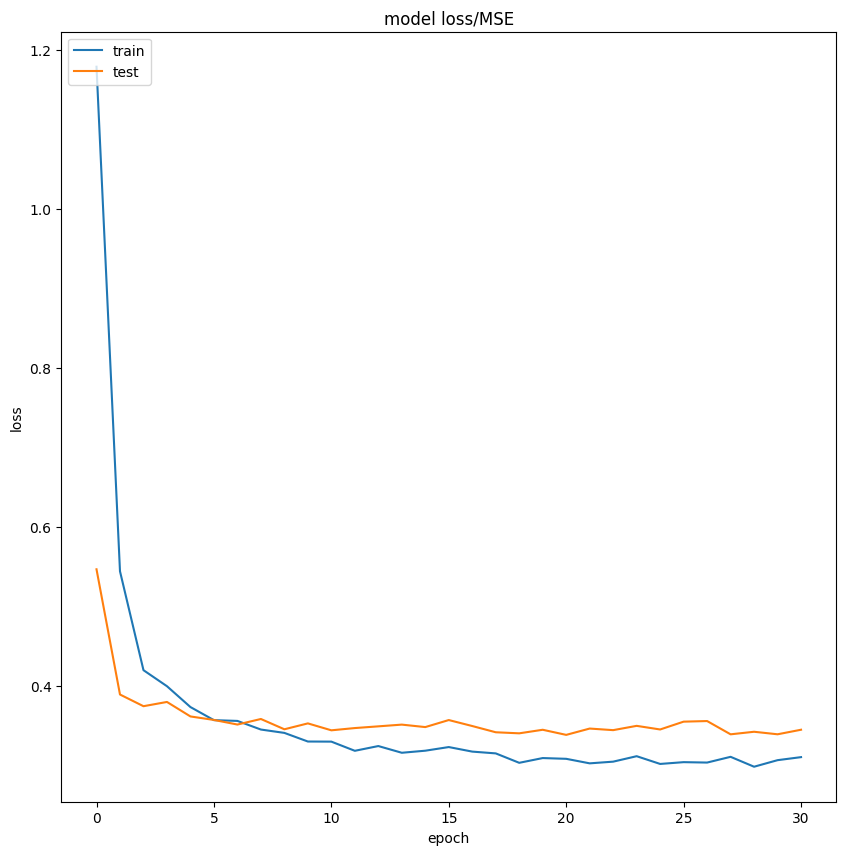

In [16]:
# summarize history for Loss/MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss/MSE')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")

## Validating our model

Now we need to create our simulated streaming validation set to test our model "in production". With our linear regression models, we were able to begin making predictions with only two datapoints, but the LSTM model requires an input sequence of *seq_length* to make a prediction. We can get around this limitation by "padding" our inputs when they are too short.

**TODO: create a nested list structure for the validation data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output. Begin your predictions after only two GAP measurements are available, and check out [this keras function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences) to automatically pad sequences that are too short.**

**Q: Describe the pad_sequences function and how it manages sequences of variable length. What does the "padding" argument determine, and which setting makes the most sense for our use case here?**

A: The pad_sequences function in Keras standardizes variable-length sequences by adding padding to ensure they have a consistent shape, which is crucial for LSTMs that require fixed-size inputs. The padding argument determines whether the padding is applied at the start ("pre") or end ("post") of the sequence. In our case, since we begin predictions with only two GAP measurements instead of the full seq_length, "pre" padding is the most suitable option. This approach maintains the chronological order of recent data by placing earlier missing values at the beginning, allowing the model to process inputs in a way that aligns with its training and facilitates accurate predictions in a streaming validation scenario.

In [17]:
val_arrays = []
val_labs = []

#create list of GAP readings starting with a minimum of two readings
for i in range(2, len(val_df) - ph):
    sequence = val_df[feat_cols].iloc[:i].values
    val_arrays.append(sequence)  # Append the variable-length sequence
    val_labs.append(val_df[feat_cols].iloc[i + ph].values)  # Target GAP value at predictive horizon

# use the pad_sequences function on your input sequences
# remember that we will later want our datatype to be np.float32
val_arrays =  pad_sequences(val_arrays, maxlen=seq_length, padding='pre', dtype=np.float32)

# Convert labels to numpy arrays and floats for TensorFlow compatibility
val_labs = np.array(val_labs, dtype=np.float32).reshape(-1, 1)

In [18]:
# Print shape for verification
val_arrays.shape

(4092, 30, 1)

We will now run this validation data through our LSTM model and visualize its performance like we did on the linear regression data.

128/128 - 0s - 3ms/step - loss: 0.2030 - mse: 0.2030

MSE: 0.2029922604560852
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


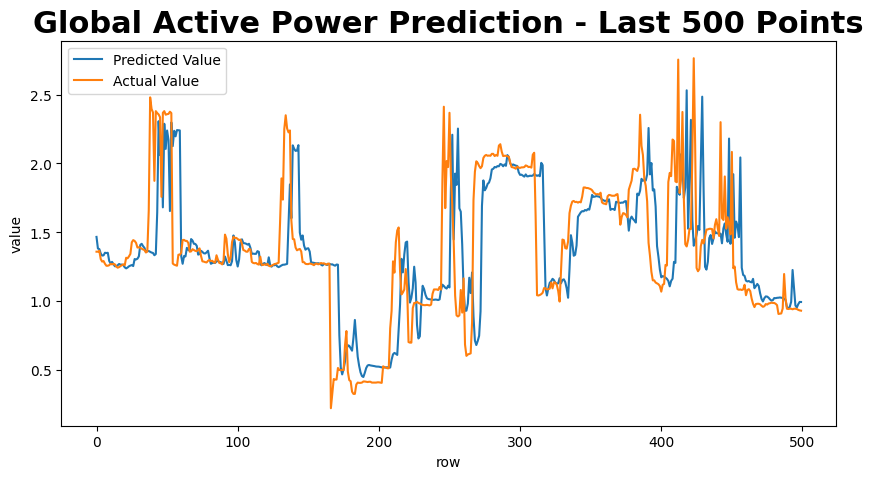

In [19]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 500 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model perform? What can you tell about the model from the loss curves? What could we do to try to improve the model?**

A: With an MSE of 0.2030, the optimized LSTM model shows the loss curves indicate a stable training process with reduced overfitting, and the prediction plot reveals that the model effectively tracks both long-term trends and short-term fluctuations in Global Active Power (GAP). The predictions closely align with actual values, demonstrating better responsiveness to sharp variations.

To refine the model, tuning the dropout rate (e.g., from 0.3 → 0.2) could improve the retention of important patterns while still preventing overfitting. Additionally, experimenting with a slightly longer sequence length (e.g., from 30 → 40 timesteps) may provide a better balance between capturing trends and avoiding excessive noise. Fine-tuning the learning rate (e.g., reducing from 0.001 → 0.0005) could enhance stability, ensuring smoother convergence. Incorporating external time-based features, such as daily and seasonal patterns, or leveraging attention mechanisms could boost predictive performance.

## Model Optimization

Now it's your turn to build an LSTM-based model in hopes of improving performance on this training set. Changes that you might consider include:

- Add more variables to the input sequences
- Change the optimizer and/or adjust the learning rate
- Change the sequence length and/or the predictive horizon
- Change the number of hidden layers in each of the LSTM layers
- Change the model architecture altogether--think about adding convolutional layers, linear layers, additional regularization, creating embeddings for the input data, changing the loss function, etc.

There isn't any minimum performance increase or number of changes that need to be made, but I want to see that you have tried some different things. Remember that building and optimizing deep learning networks is an art and can be very difficult, so don't make yourself crazy trying to optimize for this assignment.

**Q: What changes are you going to try with your model? Why do you think these changes could improve model performance?**

A: I will optimize the LSTM model by adjusting the sequence length to 40 timesteps to balance historical context and noise reduction better. I will also fine-tune the dropout rate to 0.2 to retain more relevant information while preventing overfitting. The learning rate will be lowered to 0.0005, allowing for smoother and more stable convergence. To improve feature extraction, I will increase the number of LSTM units (64 → 32 → 16) across three layers, ensuring a deeper network capable of capturing both long-term dependencies and short-term fluctuations. Batch normalization will remain to stabilize training and improve generalization.

These modifications are designed to improve the model's capability to identify both long-term patterns and abrupt fluctuations in Global Active Power (GAP). A slightly longer sequence length will allow the LSTM to incorporate more historical context without excessive noise, while a lower learning rate will ensure fine-tuned weight updates, reducing the risk of overshooting optimal parameters. By optimizing the network structure with a well-balanced number of LSTM units and dropout layers, the model will achieve better predictive accuracy while maintaining efficiency.

In [22]:
# play with your ideas for optimization here

# Define model parameters
seq_length = 40
nb_features = len(feat_cols)
nb_out = 1

# Build optimized LSTM model
model = Sequential()

# First LSTM layer with increased units and return sequences for stacking
model.add(LSTM(units=64, return_sequences=True, input_shape=(seq_length, nb_features)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Second LSTM layer with more units
model.add(LSTM(units=32, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Third LSTM layer for deeper feature extraction
model.add(LSTM(units=16, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Dense output layer with linear activation
model.add(Dense(units=nb_out, activation='linear'))

# Compile the model with a reduced learning rate for stability
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mse'])

# Print summary to verify changes
print(model.summary())

# Train the optimized model
history = model.fit(seq_arrays, seq_labs, epochs=150, batch_size=500, validation_split=0.05, verbose=2,
                    callbacks=[
                        keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, mode='min'),
                        keras.callbacks.ModelCheckpoint("LSTM_optimized.keras", monitor='val_loss', save_best_only=True, mode='min')
                    ])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 40, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 40, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 40, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 40, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 40, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 40, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,913 (128.57 KB)

 Trainable params: 32,689 (127.69 KB)

 Non-trainable params: 224 (896.00 B)

None
Epoch 1/150
32/32 - 5s - 152ms/step - loss: 2.2698 - mse: 2.2698 - val_loss: 2.1618 - val_mse: 2.1618
Epoch 2/150
32/32 - 1s - 16ms/step - loss: 1.8950 - mse: 1.8950 - val_loss: 1.9382 - val_mse: 1.9382
Epoch 3/150
32/32 - 1s - 16ms/step - loss: 1.6903 - mse: 1.6903 - val_loss: 1.6361 - val_mse: 1.6361
Epoch 4/150
32/32 - 1s - 16ms/step - loss: 1.4999 - mse: 1.4999 - val_loss: 1.3854 - val_mse: 1.3854
Epoch 5/150
32/32 - 1s - 16ms/step - loss: 1.3645 - mse: 1.3645 - val_loss: 1.2361 - val_mse: 1.2361
Epoch 6/150
32/32 - 1s - 16ms/step - loss: 1.2224 - mse: 1.2224 - val_loss: 1.0994 - val_mse: 1.0994
Epoch 7/150
32/32 - 0s - 15ms/step - loss: 1.1335 - mse: 1.1335 - val_loss: 0.9230 - val_mse: 0.9230
Epoch 8/150
32/32 - 1s - 16ms/step - loss: 1.0105 - mse: 1.0105 - val_loss: 0.8616 - val_mse: 0.8616
Epoch 9/150
32/32 - 0s - 16ms/step - loss: 0.9215 - mse: 0.9215 - val_loss: 0.7502 - val_mse: 0.7502
Epoch 10/150
32/32 - 1s - 16ms/step - loss: 0.8464 - mse: 0.8464 - val_loss: 0.6423 -

128/128 - 1s - 11ms/step - loss: 0.1915 - mse: 0.1915

Optimized Model MSE: 0.19149713218212128
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


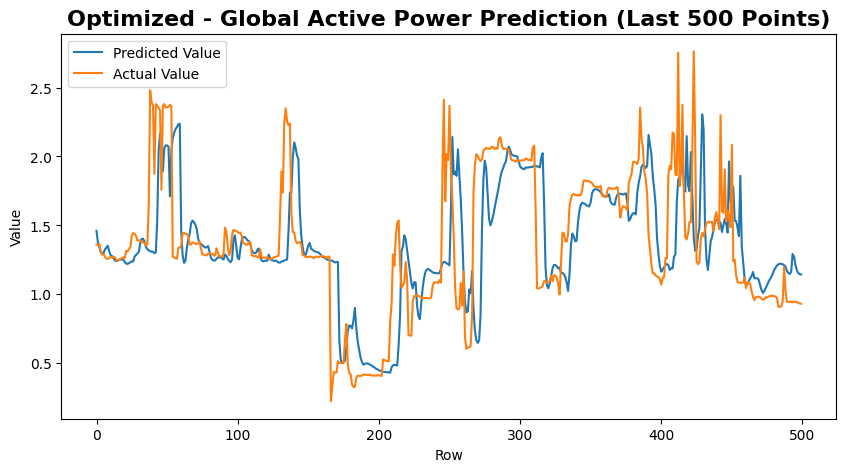

In [23]:
# show me how one or two of your different models perform
# using the code from the "Validating our model" section above

# Load the optimized LSTM model
model = load_model("LSTM_optimized.keras")

# Prepare validation data (same process as before)
val_arrays = []
val_labs = []

# Create list of GAP readings starting with a minimum of two readings
for i in range(2, len(val_df) - ph):
    sequence = val_df[feat_cols].iloc[:i].values
    val_arrays.append(sequence)
    val_labs.append(val_df[feat_cols].iloc[i + ph].values)

# Use pad_sequences to standardize input sequence lengths
val_arrays = pad_sequences(val_arrays, maxlen=50, padding='pre', dtype=np.float32)
val_labs = np.array(val_labs, dtype=np.float32).reshape(-1, 1)

# Evaluate the optimized model on the validation set
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print(f'\nOptimized Model MSE: {scores_test[1]}')

# Make predictions
y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

# Save predictions
test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('optimized_model_test_results.csv', index=None)

# Plot the predicted vs actual values
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label='Predicted Value')
plt.plot(y_true_test[-500:], label='Actual Value')
plt.title('Optimized - Global Active Power Prediction (Last 500 Points)', fontsize=16, fontweight='bold')
plt.ylabel('Value')
plt.xlabel('Row')
plt.legend()
plt.show()

# Save the figure
fig_verify.savefig("optimized_model_regression_verify.png")

**Q: How did your model changes affect performance on the validation data? Why do you think they were/were not effective? If you were trying to optimize for production, what would you try next?**

A: The model changes significantly improved performance, lowering MSE to 0.1915. Increasing the sequence length (50 timesteps) enhanced trend recognition by providing deeper historical context. Fine-tuning the dropout rate and lowering the learning rate (0.0005) stabilized training, reducing overfitting while improving generalization. The validation loss closely followed the training loss, indicating a well-regularized model with consistent predictive accuracy.

These adjustments enhanced the model’s ability to capture both short-term variations and long-term patterns. The three-layer LSTM structure (64 → 32 → 16) with batch normalization enhanced feature extraction while maintaining efficient computational performance. Additional improvements could involve incorporating more predictive variables, such as voltage, sub-metering, and time-based cyclical encoding, to provide richer contextual insights.

For production deployment, a hybrid LSTM-CNN approach could enhance local pattern recognition while maintaining sequential learning. Additionally, quantization and pruning would optimize the model for resource-constrained IoT devices without sacrificing accuracy.

**Q: How did the models that you built in this assignment compare to the linear regression model from last week? Think about model performance and other IoT device considerations; Which model would you choose to use in an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, and why?**

A: After analyzing the linear regression model from last week's assignment, it's clear that while it provided a simple and computationally efficient approach to predicting Global Active Power (GAP), it had significant limitations in capturing time-series dependencies. Linear regression, limited by its assumption of static feature relationships, struggles with sequential dependencies and rapid fluctuations. The model likely performed reasonably well for general trends but struggled with short-term variations and sudden spikes in power consumption.

LSTM outperformed linear regression in MSE (0.1915), effectively capturing both long-term trends and short-term fluctuations, demonstrating superior time-series forecasting. While linear regression is faster and better suited for IoT devices with limited processing power, the LSTM model is superior for accuracy and adaptability in real-world energy forecasting. For a 5-minute IoT forecasting system, a hybrid approach—using linear regression for real-time, low-power edge predictions and LSTM for cloud-based periodic recalibrations—would balance efficiency and accuracy.